In [1]:
# Mount Google Drive (run this cell and follow the auth link)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

results = pd.read_csv("/content/drive/MyDrive/constraint_search_results_full.csv")
assert len(results) == 50*(1+6+18+18+18+18)

qwen_baseline_results = pd.read_csv("/content/drive/MyDrive/qwen_humanized_baseline.csv")
gpt_baseline_results = pd.read_csv("/content/drive/MyDrive/gpt_baseline_results.csv")
coherence_scores = pd.read_csv("/content/drive/MyDrive/coherence_scores_final.csv")

Initial rows in results: 3950
Rows after cleaning (valid numeric depth & detector_score): 3950
Rows dropped due to missing/invalid values: 0

Summary (first 10 rows):
 depth  count     mean      std   median
     0     50 0.851025 0.071900 0.869845
     1    300 0.782733 0.185361 0.865946
     2    900 0.676748 0.254345 0.826902
     3    900 0.537561 0.289498 0.594740
     4    900 0.493569 0.291057 0.422394
     5    900 0.449558 0.282114 0.311188


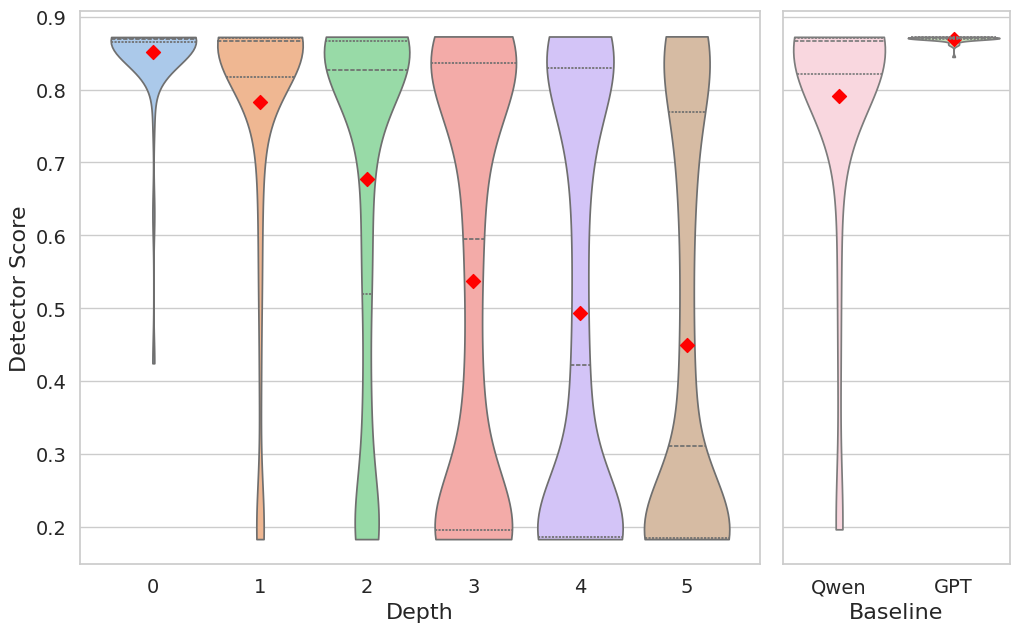

In [3]:
# Two-panel violin plot: left = depths, right = two baselines (Qwen, GPT)
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="muted", context="notebook")
sns.set_context("notebook", rc={
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13
})

# --- 1. Validate and clean the main DataFrame ---
_required_cols = {"depth", "detector_score"}
_missing_cols = _required_cols - set(results.columns)
if _missing_cols:
    raise ValueError(f"results DataFrame is missing required columns: {_missing_cols}")

df = results.copy()
df['depth_orig'] = df['depth']
df['score_orig'] = df['detector_score']

df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['detector_score'] = pd.to_numeric(df['detector_score'], errors='coerce')

initial_rows = len(df)
df_clean = df.dropna(subset=['depth', 'detector_score']).copy()

if not df_clean['depth'].empty:
    if np.all(np.isclose(df_clean['depth'], np.round(df_clean['depth']))):
        df_clean['depth'] = df_clean['depth'].round().astype(int)
    else:
        df_clean['depth'] = df_clean['depth'].astype(float)

rows_after_clean = len(df_clean)
rows_dropped = initial_rows - rows_after_clean

print(f"Initial rows in results: {initial_rows}")
print(f"Rows after cleaning (valid numeric depth & detector_score): {rows_after_clean}")
print(f"Rows dropped due to missing/invalid values: {rows_dropped}")

if df_clean.empty:
    raise ValueError("No valid rows remain after cleaning. Cannot create visualizations.")

# --- 2. Prepare baseline DataFrames ---
def prepare_baseline_df(baseline_df, score_col, label):
    if baseline_df is None:
        return pd.DataFrame(columns=['label', 'detector_score'])
    if score_col not in baseline_df.columns:
        raise ValueError(f"Baseline dataframe for {label} missing required column: {score_col}")
    tmp = baseline_df[[score_col]].rename(columns={score_col: 'detector_score'}).copy()
    tmp['label'] = label
    return tmp

qwen_df = prepare_baseline_df(globals().get('qwen_baseline_results', None), 'humanized_detector_score', 'Qwen')
gpt_df  = prepare_baseline_df(globals().get('gpt_baseline_results', None),  'humanized_detector_score', 'GPT')

df_baselines = pd.concat([qwen_df, gpt_df], ignore_index=True)

# --- 3. Summary diagnostics (optional) ---
summary = df_clean.groupby('depth')['detector_score'].agg(['count', 'mean', 'std', 'median']).reset_index().sort_values('depth')
print("\nSummary (first 10 rows):")
print(summary.head(10).to_string(index=False))

# --- 4. Plot: two subplots side-by-side with shared y-axis ---
unique_numeric_depths = np.sort(df_clean['depth'].unique())
numeric_labels = [str(d) for d in unique_numeric_depths]

# Choose width ratio so depths panel is wider than baseline panel
left_width = max(4, len(numeric_labels))
right_width = 2
fig, axs = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 7),
    gridspec_kw={'width_ratios': [left_width, right_width]},
    sharey=True
)

# Left panel Depths
ax_left = axs[0]
sns.violinplot(
    data=df_clean.assign(depth_str=df_clean['depth'].astype(str)),
    x='depth_str',
    y='detector_score',
    order=numeric_labels,
    inner='quartile',
    scale='width',
    cut=0,
    palette='pastel',
    ax=ax_left
)
means_left = df_clean.groupby('depth')['detector_score'].mean().reindex(unique_numeric_depths)
x_pos_left = np.arange(len(numeric_labels))
ax_left.scatter(x_pos_left, means_left.values, color='red', marker='D', s=50, label='Mean')
ax_left.set_xlabel("Depth")
ax_left.set_ylabel("Detector Score")
ax_left.tick_params(axis='x')
ax_left.tick_params(axis='y')

# Right panel Baselines
ax_right = axs[1]
if df_baselines.empty:
    ax_right.text(0.5, 0.5, "No baseline data\n(qwen_baseline_results / gpt_baseline_results)",
                  ha='center', va='center', fontsize=11, color='gray')
    ax_right.set_xticks([])
else:
    sns.violinplot(
        data=df_baselines,
        x='label',
        y='detector_score',
        order=['Qwen', 'GPT'],
        inner='quartile',
        scale='width',
        cut=0,
        palette=['#ffd1dc', '#c7e9b4'],
        ax=ax_right
    )
    means_right = df_baselines.groupby('label')['detector_score'].mean().reindex(['Qwen', 'GPT'])
    x_pos_right = np.arange(len(means_right))
    ax_right.scatter(x_pos_right, means_right.values, color='red', marker='D', s=50)
    ax_right.set_xlabel("Baseline")  # only use "Depth" label on the left panel
    ax_right.set_ylabel("")  # hide duplicate y-label
    ax_right.tick_params(axis='x')

# Align y-limits explicitly to ensure identical vertical scale
ax_right.set_ylim(ax_left.get_ylim())

# Single supertitle
#plt.suptitle("Distribution of Detector Scores per Depth with Baselines", fontsize=16, y=0.98)
plt.subplots_adjust(wspace=0.05, top=0.90)

# Remove duplicate legend if present
handles, labels = ax_left.get_legend_handles_labels()
if handles:
    ax_left.legend().remove()

plt.show()


Initial rows: 3950
Rows after cleaning: 3950 (dropped 0)
Unique depths: 6 (sample: [0 1 2 3 4 5])
Prompt types (order): ['creative_writing', 'factual', 'opinion', 'step_by_step', 'problem_solving']


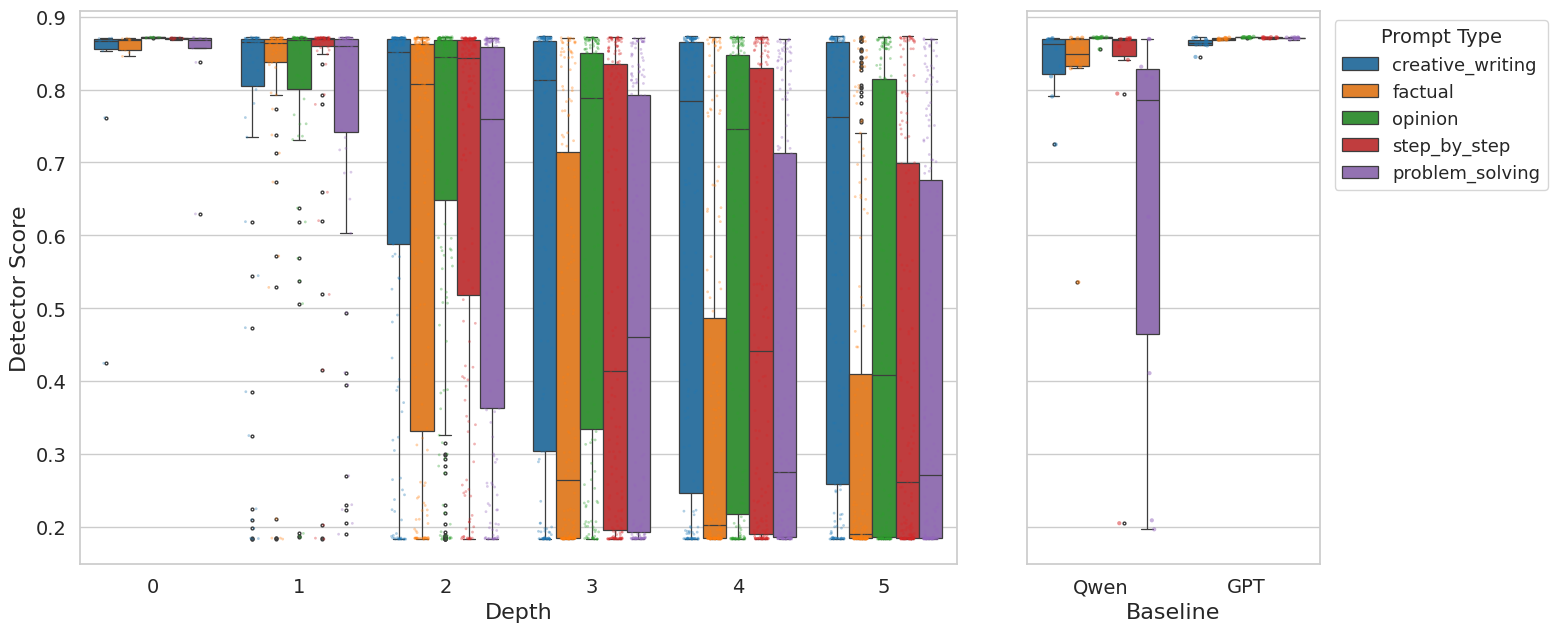

In [ ]:
# Two-panel: Boxplot by Depth (left) and Boxplot of two Baselines (right)

# --- 1) Validate and clean main DataFrame (results) ---
_required = {"depth", "detector_score", "prompt_type"}
_missing = _required - set(results.columns)
if _missing:
    raise ValueError(f"results DataFrame is missing required columns: {_missing}")

df = results.copy()

# keep originals for diagnostics if needed
df["_depth_orig"] = df["depth"]
df["_score_orig"] = df["detector_score"]

# coerce numeric
df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
df["detector_score"] = pd.to_numeric(df["detector_score"], errors="coerce")

initial_n = len(df)
df = df.dropna(subset=["depth", "detector_score", "prompt_type"])
after_drop_n = len(df)
dropped = initial_n - after_drop_n

# if depth is integer-like, convert to int for grouping
if not df["depth"].empty and np.all(np.isclose(df["depth"], np.round(df["depth"]))):
    df["depth"] = df["depth"].round().astype(int)

# normalize prompt_type strings
df["prompt_type"] = df["prompt_type"].astype(str).str.strip()

# build a sensible prompt_type order (preserve preferred order if present)
preferred_order = ['creative_writing', 'factual', 'opinion', 'step_by_step', 'problem_solving']
present_preferred = [p for p in preferred_order if p in df["prompt_type"].unique()]
if present_preferred:
    prompt_order = present_preferred + [p for p in df["prompt_type"].unique() if p not in present_preferred]
else:
    prompt_order = df["prompt_type"].value_counts().index.tolist()

# set categorical dtype for consistent hue ordering
df["prompt_type"] = pd.Categorical(df["prompt_type"], categories=prompt_order, ordered=True)

# diagnostics (optional)
print(f"Initial rows: {initial_n}")
print(f"Rows after cleaning: {after_drop_n} (dropped {dropped})")
unique_depths = np.sort(df["depth"].unique())
print(f"Unique depths: {len(unique_depths)} (sample: {unique_depths[:20]})")
print(f"Prompt types (order): {prompt_order}")

if df.empty:
    raise ValueError("No valid rows remain after cleaning. Cannot create visualizations.")

# --- 2) Prepare baseline DataFrames (qwen_baseline_results, gpt_baseline_results) ---
def prepare_baseline_df(baseline_df, score_col, label):
    """Return DataFrame with columns: label, detector_score, prompt_type"""
    if baseline_df is None:
        return pd.DataFrame(columns=["label", "detector_score", "prompt_type"])
    if score_col not in baseline_df.columns:
        raise ValueError(f"Baseline dataframe for {label} missing required column: {score_col}")
    if "prompt_type" not in baseline_df.columns:
        raise ValueError(f"Baseline dataframe for {label} missing required column: prompt_type")
    tmp = baseline_df[[score_col, "prompt_type"]].rename(columns={score_col: "detector_score"}).copy()
    tmp["label"] = label
    # normalize prompt_type strings to match main df
    tmp["prompt_type"] = tmp["prompt_type"].astype(str).str.strip()
    return tmp

qwen_df = prepare_baseline_df(globals().get("qwen_baseline_results", None), "humanized_detector_score", "Qwen")
gpt_df  = prepare_baseline_df(globals().get("gpt_baseline_results", None),  "humanized_detector_score", "GPT")

df_baselines = pd.concat([qwen_df, gpt_df], ignore_index=True)

# If baselines contain prompt types not present in main df, extend prompt_order so hue mapping is consistent
baseline_prompt_types = sorted(df_baselines["prompt_type"].dropna().unique())
for p in baseline_prompt_types:
    if p not in prompt_order:
        prompt_order.append(p)

# Ensure categorical dtype for baselines too
if not df_baselines.empty:
    df_baselines["prompt_type"] = pd.Categorical(df_baselines["prompt_type"], categories=prompt_order, ordered=True)

# --- 3) Choose depths to show in the left boxplot (limit for readability) ---
max_depths_shown = 20
depth_counts = df["depth"].value_counts().sort_values(ascending=False)
if len(depth_counts) > max_depths_shown:
    depths_for_box = sorted(depth_counts.index[:max_depths_shown])
    subtitle = f"(showing top {max_depths_shown} depths by frequency)"
else:
    depths_for_box = list(unique_depths)
    subtitle = ""

box_df = df[df["depth"].isin(depths_for_box)].copy()

# --- 4) Create side-by-side figure: left = depths boxplot, right = baselines boxplot ---
left_width = max(4, len(depths_for_box))
right_width = 2
fig, (ax_left, ax_right) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [left_width, right_width]},
    sharey=True
)

# Left: boxplot by depth with hue=prompt_type
sns.boxplot(
    data=box_df,
    x="depth",
    y="detector_score",
    hue="prompt_type",
    order=depths_for_box,
    hue_order=prompt_order,
    palette=sns.color_palette("tab10", n_colors=max(3, len(prompt_order))),
    fliersize=2,
    linewidth=0.9,
    ax=ax_left
)
# overlay jittered points (dodge so points align with hue)
sns.stripplot(
    data=box_df,
    x="depth",
    y="detector_score",
    hue="prompt_type",
    order=depths_for_box,
    hue_order=prompt_order,
    dodge=True,
    jitter=0.25,
    size=2,
    alpha=0.35,
    palette=sns.color_palette("tab10", n_colors=max(3, len(prompt_order))),
    ax=ax_left
)
# prevent stripplot points from creating legend entries on the left
for coll in ax_left.collections:
    coll.set_label('_nolegend_')

ax_left.set_xlabel("Depth")
ax_left.set_ylabel("Detector Score")

# Right: baselines boxplot (use label as x)
if df_baselines.empty:
    ax_right.text(0.5, 0.5, "No baseline data\n(qwen_baseline_results / gpt_baseline_results)",
                  ha="center", va="center", color="gray")
    ax_right.set_xticks([])
    ax_right.set_xlabel("")  # per request, only left x-axis labeled "Depth"
    ax_right.set_ylabel("")  # shared y-axis, hide duplicate label
else:
    sns.boxplot(
        data=df_baselines,
        x="label",
        y="detector_score",
        hue="prompt_type",
        order=["Qwen", "GPT"],
        hue_order=prompt_order,
        palette=sns.color_palette("tab10", n_colors=max(3, len(prompt_order))),
        fliersize=2,
        linewidth=0.9,
        ax=ax_right
    )
    sns.stripplot(
        data=df_baselines,
        x="label",
        y="detector_score",
        hue="prompt_type",
        order=["Qwen", "GPT"],
        hue_order=prompt_order,
        dodge=True,
        jitter=0.25,
        size=3,
        alpha=0.5,
        palette=sns.color_palette("tab10", n_colors=max(3, len(prompt_order))),
        ax=ax_right
    )
    # prevent stripplot points from creating legend entries on the right
    for coll in ax_right.collections:
        coll.set_label('_nolegend_')

    ax_right.set_xlabel("Baseline")  # only use "Depth" label on the left per request
    ax_right.set_ylabel("")  # shared y-axis
    ax_right.tick_params(axis="x", rotation=0)
    ax_right.tick_params(axis="y")

# Create legend using the right plot's handles (boxplot handles remain) and remove any legend on the left
handles, labels = ax_right.get_legend_handles_labels()
n_hues = len(prompt_order)
if handles:
    leg = ax_right.legend(handles[:n_hues], labels[:n_hues], title="Prompt Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    leg.get_title().set_fontsize(14)
# ensure left plot has no legend
if ax_left.get_legend() is not None:
    ax_left.get_legend().remove()

# Align y-limits explicitly to ensure identical vertical scale
ax_right.set_ylim(ax_left.get_ylim())

# Single supertitle
#plt.suptitle("Relationship Between Depth and Detector Score", y=0.98)

# Reduce horizontal space between subplots for a neat, close layout
plt.subplots_adjust(wspace=0.12, top=0.90)

plt.show()


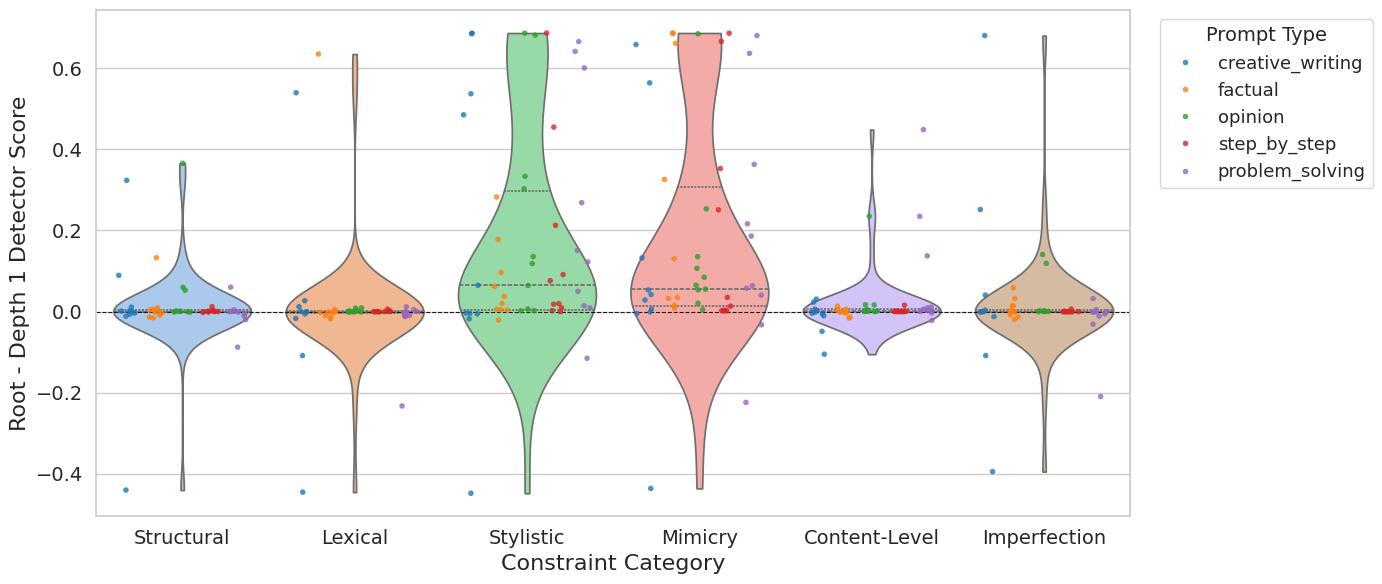

Total depth==1 rows: 300

Counts per applied_category (plotted):
applied_category_plot
Structural Constraints       50
Lexical Constraints          50
Stylistic Constraints        50
Mimicry Constraints          50
Content-Level Constraints    50
Imperfection Constraints     50

Summary statistics (by applied_category_plot):
                            n  mean_score  median_score  mean_improvement  median_improvement
applied_category_plot                                                                        
Structural Constraints     50    0.840949      0.869802          0.010076            0.000051
Lexical Constraints        50    0.843755      0.869742          0.007271           -0.000299
Stylistic Constraints      50    0.671987      0.792999          0.179039            0.064497
Mimicry Constraints        50    0.669151      0.809614          0.181875            0.056555
Content-Level Constraints  50    0.831113      0.867792          0.019912            0.000603
Imperfection Co

In [ ]:
# --- 0. Basic validation ---
_required = {"node_id", "parent_id", "depth", "applied_category", "prompt_type", "detector_score"}
_missing = _required - set(results.columns)
if _missing:
    raise ValueError(f"results DataFrame is missing required columns: {_missing}")

df = results.copy()

# Normalize and coerce types
df["node_id"] = df["node_id"].astype(str).str.strip()
df["parent_id"] = df["parent_id"].astype(str).str.strip().replace({"nan": "", "None": ""})
df["applied_category"] = df["applied_category"].astype(str).fillna("").str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).fillna("").str.strip()
df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
df["detector_score"] = pd.to_numeric(df["detector_score"], errors="coerce")

# Keep only rows with valid depth and detector_score
df = df.dropna(subset=["depth", "detector_score"]).reset_index(drop=True)

# Ensure node_id uniqueness (required for parent lookup)
if df["node_id"].duplicated().any():
    raise ValueError("node_id values are not unique; parent lookup requires unique node_id values.")

# Build lookup for root scores by node_id
node_score_lookup = df.set_index("node_id")["detector_score"].to_dict()

# Filter to depth == 1
df_d1 = df[df["depth"] == 1].copy()
if df_d1.empty:
    raise ValueError("No rows with depth == 1 found in the DataFrame.")

# Ensure every depth-1 row has a parent_id and that parent exists in the lookup
missing_parent_mask = df_d1["parent_id"].isin(["", "nan", "None"]) | (~df_d1["parent_id"].isin(node_score_lookup.keys()))
if missing_parent_mask.any():
    missing_ids = df_d1.loc[missing_parent_mask, "node_id"].tolist()
    raise ValueError(f"Some depth==1 rows have missing or unknown parent_id. Affected node_id(s): {missing_ids}")

# Compute root_score and improvement (root_score - node_score)
df_d1["root_score"] = df_d1["parent_id"].map(node_score_lookup).astype(float)
df_d1["node_score"] = df_d1["detector_score"].astype(float)
df_d1["improvement"] = df_d1["root_score"] - df_d1["node_score"]  # positive => detector score decreased (improved)

# Order applied_category by frequency for consistent plotting
applied_order = df_d1["applied_category"].value_counts().index.tolist()

# Order prompt_type by preferred mapping if present, else by frequency
preferred_prompt_order = ['creative_writing', 'factual', 'opinion', 'step_by_step', 'problem_solving']
present_preferred = [p for p in preferred_prompt_order if p in df_d1["prompt_type"].unique()]
if present_preferred:
    prompt_order = present_preferred + [p for p in df_d1["prompt_type"].unique() if p not in present_preferred]
else:
    prompt_order = df_d1["prompt_type"].value_counts().index.tolist()

# Palette for prompt_type
palette = sns.color_palette("tab10", n_colors=max(3, len(prompt_order)))

# --- 1. Prepare plotting DataFrames ---
# For plotting clarity, convert applied_category to categorical with the chosen order
df_d1["applied_category"] = pd.Categorical(df_d1["applied_category"], categories=applied_order, ordered=True)
df_d1["prompt_type"] = pd.Categorical(df_d1["prompt_type"], categories=prompt_order, ordered=True)

# If there are many applied categories, consider showing only the top N in the plots and grouping the rest as "other"
max_categories_to_show = 12
if len(applied_order) > max_categories_to_show:
    top_cats = applied_order[:max_categories_to_show]
    df_d1["applied_category_plot"] = df_d1["applied_category"].where(df_d1["applied_category"].isin(top_cats), other="other")
    plot_cat_order = top_cats + ["other"]
else:
    df_d1["applied_category_plot"] = df_d1["applied_category"]
    plot_cat_order = applied_order

# --- 2. Create single residual plot (improvement) with legend titled "Prompt Type" size 14 ---
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

sns.violinplot(
    data=df_d1,
    x="applied_category_plot",
    y="improvement",
    order=plot_cat_order,
    inner="quartile",
    cut=0,
    palette="pastel",
    ax=ax
)

# overlay jittered points colored by prompt_type
sns.stripplot(
    data=df_d1,
    x="applied_category_plot",
    y="improvement",
    order=plot_cat_order,
    hue="prompt_type",
    hue_order=prompt_order,
    palette=palette,
    dodge=True,
    jitter=0.25,
    size=4,
    alpha=0.8,
    ax=ax
)

# Prevent stripplot points from creating legend entries (suppress collection labels)
for coll in ax.collections:
    coll.set_label('_nolegend_')

# Draw zero line
ax.axhline(0, color="k", linestyle="--", linewidth=0.8)

#ax.set_title("Depth = 1: Improvement vs root (root_score - node_score) per applied_category\n(points colored by prompt_type)")
ax.set_xlabel("Constraint Category")
ax.set_ylabel("Root - Depth 1 Detector Score")
ax.tick_params(axis="x")

# Build legend from artists (boxplot handles are in the axes' artists/lines; get_legend_handles_labels will capture remaining labeled artists)
handles, labels = ax.get_legend_handles_labels()
n_hues = len(prompt_order)
if handles:
    # create legend and set title fontsize to 14
    leg = ax.legend(handles[:n_hues], labels[:n_hues], title="Prompt Type", bbox_to_anchor=(1.02, 1), loc="upper left")
    leg.get_title().set_fontsize(14)
else:
    if ax.get_legend() is not None:
        ax.get_legend().remove()

# remove 'Constraint' (case-insensitive) from x tick labels
labels = [lbl.get_text() for lbl in ax.get_xticklabels()]
new_labels = [l.replace(' Constraints', '').replace('constraint', '').strip() for l in labels]
ax.set_xticklabels(new_labels)

plt.tight_layout()
plt.show()

# --- 3. Print concise diagnostics for context ---
print(f"Total depth==1 rows: {len(df_d1)}")
counts_by_cat = df_d1["applied_category_plot"].value_counts().reindex(plot_cat_order).fillna(0).astype(int)
print("\nCounts per applied_category (plotted):")
print(counts_by_cat.to_string())

print("\nSummary statistics (by applied_category_plot):")
summary = df_d1.groupby("applied_category_plot").agg(
    n=("node_score", "count"),
    mean_score=("node_score", "mean"),
    median_score=("node_score", "median"),
    mean_improvement=("improvement", "mean"),
    median_improvement=("improvement", "median")
).reindex(plot_cat_order)
print(summary.to_string())


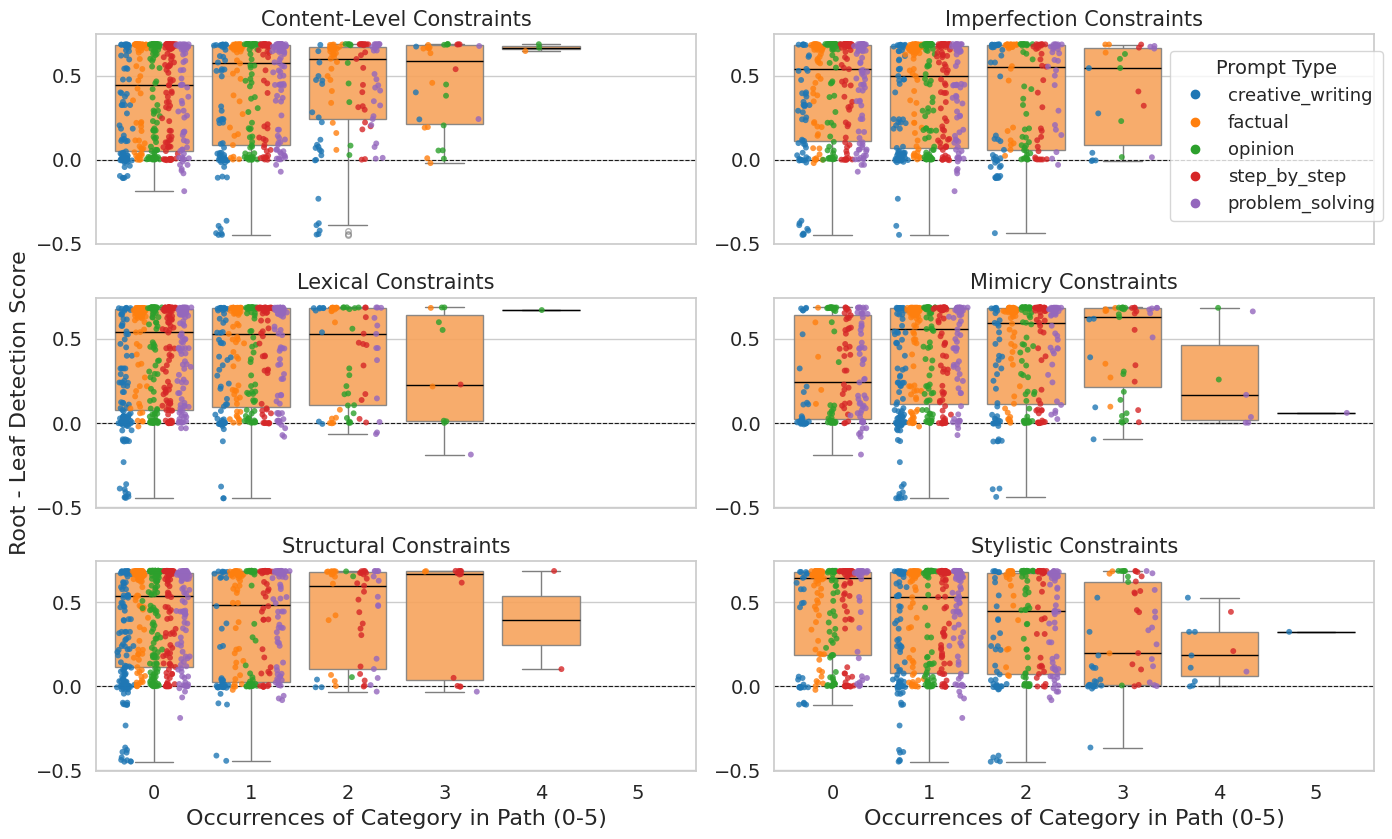

In [11]:
# Depth-5 path analysis and per-category plots
# - For every node with depth == 5, trace its ancestor chain up to the root (depth 0)
# - For each path (root -> ... -> depth-5 node) collect the 5 applied_category entries (excluding root)
# - For each of the (non-empty) applied_category values in the dataset, build buckets by how many times
#   that category appears in the 5-element path (0..5)
# - Record both the absolute detector_score at the depth-5 node and the residual (root_score - node_score)
# - Produce one row per category with two side-by-side plots:
#     Left:  absolute detector_score distribution vs count (0..5)
#     Right: residual distribution vs count (0..5)
#
# Assumptions:
# - A pandas DataFrame `results` is present in the environment with columns:
#     'node_id', 'parent_id', 'depth', 'applied_category', 'detector_score', 'prompt_type'
# - node_id values are unique and parent_id references those node_id strings (root nodes have empty parent_id)
# - This cell only displays plots (does NOT save files)

# -------------------------
# 0. Validate input
# -------------------------
_required = {"node_id", "parent_id", "depth", "applied_category", "detector_score", "prompt_type"}
_missing = _required - set(results.columns)
if _missing:
    raise ValueError(f"results DataFrame is missing required columns: {_missing}")

df = results.copy()

# Normalize and coerce types
df["node_id"] = df["node_id"].astype(str).str.strip()
df["parent_id"] = df["parent_id"].astype(str).str.strip().replace({"nan": "", "None": ""})
df["applied_category"] = df["applied_category"].astype(str).fillna("").str.strip()
df["prompt_type"] = df["prompt_type"].astype(str).fillna("").str.strip()
df["depth"] = pd.to_numeric(df["depth"], errors="coerce")
df["detector_score"] = pd.to_numeric(df["detector_score"], errors="coerce")

# Drop rows missing essential values
df = df.dropna(subset=["node_id", "depth", "detector_score"]).reset_index(drop=True)

# Ensure node_id uniqueness
if df["node_id"].duplicated().any():
    raise ValueError("node_id values are not unique. Ensure node_id uniqueness before running this analysis.")

# Build lookup for fast access
node_lookup = df.set_index("node_id").to_dict(orient="index")

# -------------------------
# 1. Robust ancestor path builder
# -------------------------
def build_path_to_root(start_node_id, max_hops=1000):
    """
    Return list of node_ids from root (depth 0) to start_node_id inclusive.
    Stops if parent link missing, parent not found, or a cycle is detected.
    """
    path = []
    seen = set()
    current = start_node_id
    hops = 0
    # Walk upward collecting nodes (start -> parent -> ...)
    while current and hops < max_hops:
        if current in seen:
            # cycle detected
            break
        seen.add(current)
        if current not in node_lookup:
            # broken link; cannot continue
            break
        path.append(current)
        parent = node_lookup[current].get("parent_id", "")
        if parent is None or str(parent).strip() == "" or str(parent).strip().lower() in {"nan", "none"}:
            break
        if str(parent) == str(current):
            break
        current = str(parent)
        hops += 1
    # path is start->...->ancestor; reverse to ancestor->...->start
    return list(reversed(path))

# -------------------------
# 2. Collect data for depth-5 nodes
# -------------------------
depth_target = 5
df_d5 = df[df["depth"] == depth_target].copy()
if df_d5.empty:
    raise ValueError(f"No rows with depth == {depth_target} found in the DataFrame.")

# Determine the set of non-empty applied categories present in the dataset
all_categories = sorted([c for c in df["applied_category"].unique() if str(c).strip() != ""])
if len(all_categories) == 0:
    raise ValueError("No non-empty applied_category values found in the DataFrame.")

# Prepare storage: data_by_cat[category][count] -> lists of node_scores, residuals, prompt_types
data_by_cat = {cat: {cnt: {"node_scores": [], "residuals": [], "prompt_types": []} for cnt in range(0, 6)} for cat in all_categories}

skipped = 0
processed = 0

for _, row in df_d5.iterrows():
    start_id = row["node_id"]
    path = build_path_to_root(start_id)
    # We require a full path of length depth_target + 1 (root + 5 nodes)
    if len(path) != depth_target + 1:
        skipped += 1
        continue
    # Extract applied_category values for the 5 non-root nodes in order (root is path[0])
    # We will exclude any empty applied_category entries; but the user expects exactly 5 applied categories.
    applied_seq = []
    valid_path = True
    for pid in path[1:]:  # skip root at index 0
        prow = node_lookup.get(pid)
        if prow is None:
            valid_path = False
            break
        cat = prow.get("applied_category", "")
        if cat is None or str(cat).strip() == "":
            # If any of the 5 positions has an empty applied_category, treat path as invalid for this strict analysis
            valid_path = False
            break
        applied_seq.append(str(cat).strip())
    if not valid_path or len(applied_seq) != depth_target:
        skipped += 1
        continue

    # Root score is detector_score of the root node (path[0])
    root_row = node_lookup.get(path[0], {})
    root_score = root_row.get("detector_score", None)
    if root_score is None or pd.isna(root_score):
        skipped += 1
        continue

    node_score = float(row["detector_score"])
    residual = float(root_score) - node_score  # positive => reduction

    prompt_type = row.get("prompt_type", "")

    # For each category, count occurrences in applied_seq and append values
    from collections import Counter
    seq_counter = Counter(applied_seq)
    for cat in all_categories:
        cnt = int(seq_counter.get(cat, 0))  # 0..5
        bucket = data_by_cat[cat][cnt]
        bucket["node_scores"].append(node_score)
        bucket["residuals"].append(residual)
        bucket["prompt_types"].append(prompt_type)

    processed += 1

# -------------------------
# 3. Build plots: one row per category, two columns (absolute, residual)
# -------------------------
# add near the top, before the plotting loop
# --- Assumes these exist in your environment ---
# data_by_cat : dict mapping category -> count -> {"node_scores": [...], "residuals": [...], "prompt_types": [...]}
# all_categories : iterable of category names

# -------------------------
# 3. Build plots: one row per category, two columns (absolute, residual)
# -------------------------
# limit to at most 6 categories and arrange them in 3 rows x 2 cols
cats_to_plot = list(all_categories)[:6]
n_plot = len(cats_to_plot)
rows, cols = 3, 2
fig_h = max(6, rows * 3.0)
fig, axes = plt.subplots(rows, cols, figsize=(14, fig_h), squeeze=False)
plt.subplots_adjust(hspace=0.6, wspace=0.28)

count_order = list(range(0, 6))

x_min = -0.6
x_max = count_order[-1] + 0.6

# -------------------------
# Desired prompt-type order and palette
# -------------------------
desired_order = [
    "creative_writing",
    "factual",
    "opinion",
    "step_by_step",
    "problem_solving",
]

# Discover all prompt types present in the plotted categories
all_found = sorted({
    pt
    for cat in cats_to_plot
    for cnt in count_order
    for pt in data_by_cat.get(cat, {}).get(cnt, {}).get("prompt_types", [])
})

# Build prompt_types_all so desired_order appears first (if present), then any extras
prompt_types_all = [pt for pt in desired_order if pt in all_found] + [pt for pt in all_found if pt not in desired_order]

# Create a consistent palette mapping for prompt types (in the exact order of prompt_types_all)
palette = sns.color_palette("tab10", n_colors=max(3, len(prompt_types_all)))
prompt_palette = {pt: palette[i % len(palette)] for i, pt in enumerate(prompt_types_all)}

# Precompute horizontal offsets for each prompt type so left-to-right ordering is deterministic
n_types = len(prompt_types_all)
dodge_width = 0.6  # total width spanned by the group of colored points around each integer x
if n_types > 1:
    offsets = np.linspace(-dodge_width / 2, dodge_width / 2, n_types)
else:
    offsets = np.array([0.0])
offset_map = {pt: offsets[i] for i, pt in enumerate(prompt_types_all)}

# Seed base for reproducible jitter across runs (optional)
base_seed = 12345

for idx, cat in enumerate(cats_to_plot):
    r = idx // cols
    c = idx % cols
    ax_res = axes[r, c]

    # Build DataFrame for residual plotting
    rows_res = []
    for cnt in count_order:
        bucket = data_by_cat.get(cat, {}).get(cnt, {"node_scores": [], "residuals": [], "prompt_types": []})
        for ns, res, pt in zip(bucket["node_scores"], bucket["residuals"], bucket["prompt_types"]):
            rows_res.append({"count": cnt, "residual": res, "prompt_type": pt})
    df_res = pd.DataFrame(rows_res)

    if df_res.empty:
        ax_res.text(0.5, 0.5, f"No valid depth-5 paths for category '{cat}'", ha="center", va="center")
        ax_res.set_axis_off()
        continue

    # Draw boxplot with low zorder so scatter points can be drawn on top
    sns.boxplot(
        data=df_res,
        x="count",
        y="residual",
        order=count_order,
        ax=ax_res,
        color="lightgray",
        showcaps=True,
        width=0.8,
        # ensure boxplot artists are drawn beneath scatter by setting zorder on props
        boxprops={"facecolor": "#f7a35c", "alpha": 0.9, "zorder": 1},
        whiskerprops={"zorder": 1},
        capprops={"zorder": 1},
        medianprops={"zorder": 2, "color": "black"},
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.6, "zorder": 1},
        zorder=1
    )

    # Force categorical ordering so we can reliably select rows per prompt type
    df_res["prompt_type"] = pd.Categorical(df_res["prompt_type"], categories=prompt_types_all, ordered=True)

    # Use a reproducible RNG per subplot so jitter is stable but different across subplots
    rng = np.random.default_rng(seed=base_seed + idx)

    # Plot each prompt_type in the exact order so left-to-right is consistent
    for i, pt in enumerate(prompt_types_all):
        sub = df_res[df_res["prompt_type"] == pt]
        if sub.empty:
            continue

        # base x positions are the integer counts
        x_base = sub["count"].to_numpy().astype(float)

        # apply fixed offset for this prompt type
        x_off = offset_map[pt]

        # small horizontal jitter so overlapping points are visible
        jitter_x = rng.normal(loc=0.0, scale=0.03, size=len(x_base))
        x_plot = x_base + x_off + jitter_x

        # vertical positions are the residuals (no vertical jitter by default)
        y_plot = sub["residual"].to_numpy()

        # draw points with consistent color and higher zorder so they appear on top of the boxplot
        jitter_x = rng.normal(loc=0.0, scale=0.02, size=len(x_base))

        ax_res.scatter(
            x_plot,
            y_plot,
            color=prompt_palette[pt],
            s=18,
            alpha=0.8,
            edgecolor='none',
            linewidth=0,
            label=pt,
            zorder=3
        )

    ax_res.set_xlim(x_min, x_max)
    ax_res.set_xticks(count_order)
    ax_res.set_xticklabels([str(i) for i in count_order])

    # Remove per-axis legend (we will create a single figure legend)
    if ax_res.get_legend() is not None:
        ax_res.get_legend().remove()

    # Axis formatting
    ax_res.axhline(0, color="k", linestyle="--", linewidth=0.8, zorder=2)
    ax_res.set_title(f"{cat}", fontsize=15)
    ax_res.set_xlabel("Occurrences of Category in Path (0-5)")
    ax_res.set_ylabel("Root - Leaf Detection Score")
    ax_res.set_xticks(count_order)
    ax_res.tick_params(axis="x", rotation=0)

# Hide any unused subplots (if fewer than 6 categories)
total_axes = rows * cols
for j in range(n_plot, total_axes):
    r = j // cols
    c = j % cols
    axes[r, c].set_visible(False)

# remove any per-axis legends to ensure only one legend exists
for r in range(rows):
    for c in range(cols):
        if axes[r, c].get_legend() is not None:
            axes[r, c].get_legend().remove()

# create proxy artists (one per prompt type) and place a single figure legend in the right margin
proxies = [axes[0, 0].plot([], [], marker='o', color=prompt_palette[pt], linestyle='')[0] for pt in prompt_types_all]
leg = fig.legend(proxies, prompt_types_all, title="Prompt Type", loc='center right', bbox_to_anchor=(1, 0.8))
leg.get_title().set_fontsize(14)

# remove y-axis labels on the right column (keep left column labels)
for r in range(rows):
    for c in range(cols):
        if c == 1 or (c == 0 and r != 1):
            axes[r, c].set_ylabel("")


# remove x-axis labels and tick labels for all but the bottom row
for r in range(rows - 1):
    for c in range(cols):
        axes[r, c].set_xlabel("")
        axes[r, c].set_xticklabels([])

plt.tight_layout(rect=[0, 0.01, 1, 0.96])
plt.show()





Rows after merge and cleaning: 3950
Coherence value counts:
coherence_score
1       9
2     313
3     699
4    2423
5     506
Name: count, dtype: int64


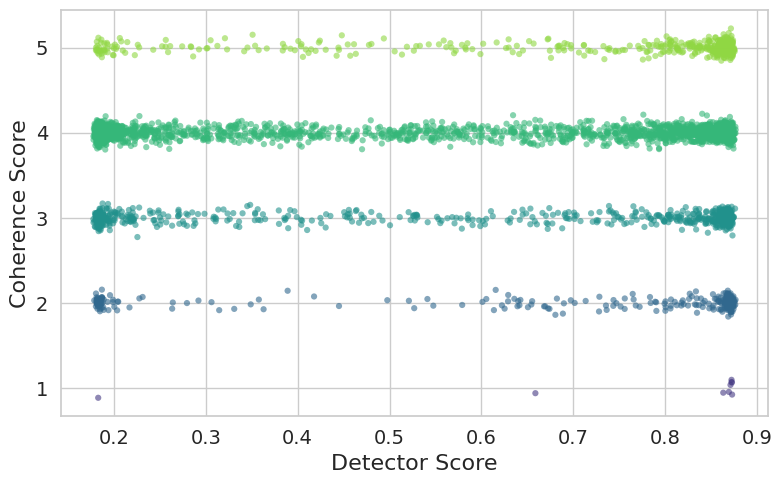

In [ ]:
# @title
# Multiple plots exploring relationship between detector_score (0..1) and coherence_score (1..5)
# Assumes `results` and `coherence_scores` DataFrames exist and both contain `node_id`.
# Do not save files; just display plots and printed summaries so you can pick the best one.

# --- 0. Merge and basic validation ---
_required_results = {"node_id", "detector_score"}
_required_coh = {"node_id", "coherence_score"}

_missing_r = _required_results - set(results.columns)
_missing_c = _required_coh - set(coherence_scores.columns)
if _missing_r:
    raise ValueError(f"results missing columns: {_missing_r}")
if _missing_c:
    raise ValueError(f"coherence_scores missing columns: {_missing_c}")

# Merge on node_id (inner join to keep only nodes with both scores)
df = results.merge(coherence_scores[["node_id", "coherence_score"]], on="node_id", how="inner")

# Coerce types and drop invalid rows
df["detector_score"] = pd.to_numeric(df["detector_score"], errors="coerce")
df["coherence_score"] = pd.to_numeric(df["coherence_score"], errors="coerce")
df = df.dropna(subset=["detector_score", "coherence_score"]).reset_index(drop=True)

# Ensure coherence is integer 1..5 (if not, round or clip)
df["coherence_score"] = df["coherence_score"].round().astype(int)
df = df[(df["coherence_score"] >= 1) & (df["coherence_score"] <= 5)].copy()

n = len(df)
print(f"Rows after merge and cleaning: {n}")
print("Coherence value counts:")
print(df["coherence_score"].value_counts().sort_index())

# If dataset is large, sample for plotting dense scatter plots
MAX_SCATTER = 20000
df_scatter = df.sample(n=min(len(df), MAX_SCATTER), random_state=42)

# --- Helper: palette for coherence levels ---
coh_order = sorted(df["coherence_score"].unique())
coh_palette = sns.color_palette("viridis", n_colors=len(coh_order))
coh_color_map = {c: coh_palette[i] for i, c in enumerate(coh_order)}

# --- 1) Simple scatter with jitter (coherence as color) ---
plt.figure(figsize=(8, 5))
plt.scatter(
    df_scatter["detector_score"] + np.random.normal(0, 0.002, size=len(df_scatter)),
    df_scatter["coherence_score"] + np.random.normal(0, 0.06, size=len(df_scatter)),
    c=[coh_color_map[c] for c in df_scatter["coherence_score"]],
    alpha=0.6,
    s=20,
    linewidths=0
)
plt.yticks(coh_order)
plt.xlabel("Detector Score")
plt.ylabel("Coherence Score")
#plt.title("Scatter: detector_score vs coherence_score (jittered)")
# add color legend proxies
proxies = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=coh_color_map[c], markersize=8) for c in coh_order]
#plt.legend(proxies, [str(c) for c in coh_order], title="Coherence", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# # --- 2) Violin + stripplot per coherence level (vertical) ---
# plt.figure(figsize=(9, 6))
# sns.violinplot(
#     data=df,
#     x="coherence_score",
#     y="detector_score",
#     order=coh_order,
#     inner="quartile",
#     palette=coh_palette,
#     cut=0
# )
# sns.stripplot(
#     data=df_scatter,
#     x="coherence_score",
#     y="detector_score",
#     order=coh_order,
#     color="k",
#     size=2,
#     alpha=0.25,
#     jitter=True
# )
# plt.xlabel("Coherence score")
# plt.ylabel("Detector score")
# plt.title("Detector score distribution per coherence level (violin + points)")
# plt.tight_layout()
# plt.show()

# # --- 3) Boxplot with mean markers and error bars (mean ± std) ---
# agg = df.groupby("coherence_score")["detector_score"].agg(["count", "mean", "std"]).reindex(coh_order)
# plt.figure(figsize=(8, 5))
# sns.boxplot(data=df, x="coherence_score", y="detector_score", order=coh_order, color="lightgray")
# plt.errorbar(
#     x=np.arange(len(coh_order)),
#     y=agg["mean"].values,
#     yerr=agg["std"].values,
#     fmt="D",
#     color="red",
#     label="mean ± std"
# )
# plt.xlabel("Coherence score")
# plt.ylabel("Detector score")
# plt.title("Boxplot per coherence level with mean ± std")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- 4) Mean detector score vs coherence (bar + CI) ---
# plt.figure(figsize=(7, 5))
# sns.barplot(data=df, x="coherence_score", y="detector_score", order=coh_order, ci=95, palette=coh_palette)
# plt.xlabel("Coherence score")
# plt.ylabel("Mean detector score (95% CI)")
# plt.title("Mean detector score by coherence (95% CI)")
# plt.tight_layout()
# plt.show()

# # --- 5) KDEs per coherence level (overlay) ---
# plt.figure(figsize=(9, 6))
# for c in coh_order:
#     subset = df[df["coherence_score"] == c]["detector_score"]
#     if len(subset) > 1:
#         sns.kdeplot(subset, label=str(c), fill=False, bw_method="scott", color=coh_color_map[c], alpha=0.8)
# plt.xlabel("Detector score")
# plt.title("KDE of detector_score by coherence level")
# plt.legend(title="Coherence")
# plt.tight_layout()
# plt.show()

# # --- 6) Hexbin / 2D density (useful for large datasets) ---
# plt.figure(figsize=(8, 6))
# hb = plt.hexbin(df["detector_score"], df["coherence_score"], gridsize=40, cmap="Blues", mincnt=1)
# plt.colorbar(hb, label="count")
# plt.xlabel("Detector score")
# plt.ylabel("Coherence score")
# plt.title("Hexbin: density of (detector_score, coherence_score)")
# plt.tight_layout()
# plt.show()

# # --- 7) Regression / trend: mean detector vs coherence with linear fit and LOWESS ---
# # Use seaborn pointplot (shows mean and CI) and overlay a lowess smooth
# plt.figure(figsize=(8, 5))
# sns.pointplot(data=df, x="coherence_score", y="detector_score", order=coh_order, color="C0", capsize=0.1)
# # LOWESS via seaborn.regplot on aggregated means (for smooth trend)
# means = df.groupby("coherence_score")["detector_score"].mean().reindex(coh_order).reset_index()
# sns.regplot(data=means, x="coherence_score", y="detector_score", scatter=False, lowess=True, color="red", label="LOWESS")
# plt.xlabel("Coherence score")
# plt.ylabel("Detector score")
# plt.title("Mean detector score by coherence with LOWESS trend")
# plt.legend()
# plt.tight_layout()
# plt.show()

# # --- 8) Faceted scatter / jitter by coherence (small multiples) ---
# g = sns.FacetGrid(df_scatter, col="coherence_score", col_wrap=5, height=2.2, sharex=True, sharey=True)
# g.map_dataframe(sns.stripplot, x="detector_score", y=np.zeros(len(df_scatter)), orient="h", size=3, color="C0", jitter=0.25)
# # adjust axes
# for ax in g.axes.flatten():
#     ax.set_yticks([])
#     ax.set_ylabel("")
# g.set_titles("Coherence = {col_name}")
# g.fig.suptitle("Jittered detector_score distributions per coherence (faceted)", y=1.02)
# plt.tight_layout()
# plt.show()

# # --- 9) If prompt_type exists, show detector vs coherence colored by prompt_type (violin split) ---
# if "prompt_type" in df.columns:
#     # violin per coherence, hue=prompt_type (only if few prompt types)
#     n_prompts = df["prompt_type"].nunique()
#     if n_prompts <= 6:
#         plt.figure(figsize=(10, 6))
#         sns.violinplot(data=df, x="coherence_score", y="detector_score", hue="prompt_type", split=False, inner="quartile", order=coh_order)
#         plt.title("Detector score by coherence, split by prompt_type")
#         plt.tight_layout()
#         plt.show()
#     # heatmap of mean detector by coherence x prompt_type
#     pivot = df.pivot_table(index="prompt_type", columns="coherence_score", values="detector_score", aggfunc="mean")
#     if not pivot.empty:
#         plt.figure(figsize=(10, max(2, 0.5 * pivot.shape[0])))
#         sns.heatmap(pivot, cmap="coolwarm", center=df["detector_score"].median(), annot=True, fmt=".2f", cbar_kws={"label": "mean detector_score"})
#         plt.title("Mean detector_score: prompt_type (rows) vs coherence (cols)")
#         plt.xlabel("Coherence score")
#         plt.ylabel("Prompt type")
#         plt.tight_layout()
#         plt.show()

# # --- 10) Boxenplot (for large datasets) to show distribution tails per coherence ---
# plt.figure(figsize=(9, 6))
# sns.boxenplot(data=df, x="coherence_score", y="detector_score", order=coh_order, palette=coh_palette)
# plt.title("Boxenplot: detector_score by coherence (shows tails)")
# plt.tight_layout()
# plt.show()

# # --- 11) Summary table and simple correlation ---
# summary = df.groupby("coherence_score")["detector_score"].agg(["count", "mean", "median", "std"]).reindex(coh_order)
# print("\nSummary by coherence score:")
# print(summary.to_string())

# # Spearman correlation (coherence is ordinal)
# from scipy.stats import spearmanr
# corr, pval = spearmanr(df["coherence_score"], df["detector_score"])
# print(f"\nSpearman correlation between coherence_score and detector_score: {corr:.4f} (p={pval:.3g})")

# # --- 12) Optional: show examples of low detector score but high coherence and vice versa ---
# # (prints a few node_ids for manual inspection)
# low_detector_high_coh = df[(df["detector_score"] < 0.2) & (df["coherence_score"] >= 4)].sort_values("detector_score").head(10)
# high_detector_low_coh = df[(df["detector_score"] > 0.8) & (df["coherence_score"] <= 2)].sort_values("detector_score", ascending=False).head(10)
# print("\nExamples: low detector score (<0.2) but high coherence (>=4):")
# print(low_detector_high_coh[["node_id", "detector_score", "coherence_score"]].to_string(index=False))
# print("\nExamples: high detector score (>0.8) but low coherence (<=2):")
# print(high_detector_low_coh[["node_id", "detector_score", "coherence_score"]].to_string(index=False))

# # End of plotting batch. Pick the plot(s) you like best and I can refine styling, add statistical tests, or produce interactive versions.
